In [1]:
#load all datasets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
price_df        = pd.read_csv("Wholesale_price_trends_20260518210002.csv", skiprows=11, sep=',')
demand_df       = pd.read_csv("Demand_trends_20260518215015.csv", skiprows=11, sep=',')
HVDC_df         = pd.read_csv("HVDC_transfer_20260518215532.csv", skiprows=10, sep=',')
lake1_df        = pd.read_csv("NI_TPO_Storage_LakeTaupo.csv")
lake2_df        = pd.read_csv("NI_WKA_Storage_LakeWaikaremoana.csv")
wind_df         = pd.read_csv("Wind_data_100m.csv")
generation_df   = pd.read_csv("Generation_trends_20260519182544.csv", skiprows=11, sep=',')

## Wholesale price per Region (9 regions)

In [3]:
#pivot regions so their prices are on the same row

price_df = price_df.pivot(index='Period start', columns='Region ID', values='Price ($/MWh)')
price_df = price_df.reset_index()

In [4]:
#display stuff
price_df.info()
price_df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87648 entries, 0 to 87647
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Period start  87648 non-null  object 
 1   BEN2201       87648 non-null  float64
 2   HAY2201       87648 non-null  float64
 3   INV2201       87648 non-null  float64
 4   ISL2201       87648 non-null  float64
 5   KIK2201       87648 non-null  float64
 6   OTA2201       87648 non-null  float64
 7   RDF2201       87648 non-null  float64
 8   SFD2201       87648 non-null  float64
 9   WKM2201       87648 non-null  float64
dtypes: float64(9), object(1)
memory usage: 6.7+ MB


Region ID,Period start,BEN2201,HAY2201,INV2201,ISL2201,KIK2201,OTA2201,RDF2201,SFD2201,WKM2201
0,01/01/2022 00:00:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
1,01/01/2022 00:30:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
2,01/01/2022 01:00:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
3,01/01/2022 01:30:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
4,01/01/2022 02:00:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
5,01/01/2022 02:30:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
6,01/01/2022 03:00:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
7,01/01/2022 03:30:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
8,01/01/2022 04:00:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
9,01/01/2022 04:30:00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01


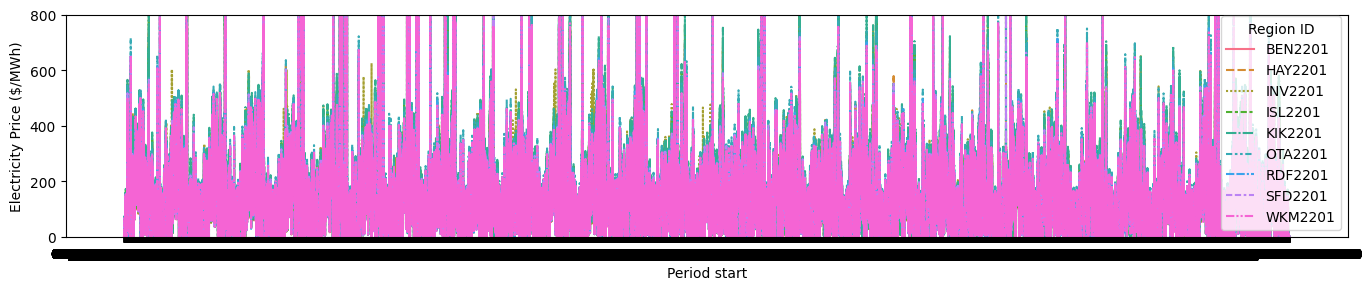

In [8]:
#display more stuff
plt.figure(figsize=(14,3))
sns.lineplot(data=price_df.set_index('Period start'), palette='husl')
plt.ylabel('Electricity Price ($/MWh)')
plt.tight_layout()
plt.ylim(0,800)
plt.show()

<Axes: xlabel='Region ID', ylabel='Region ID'>

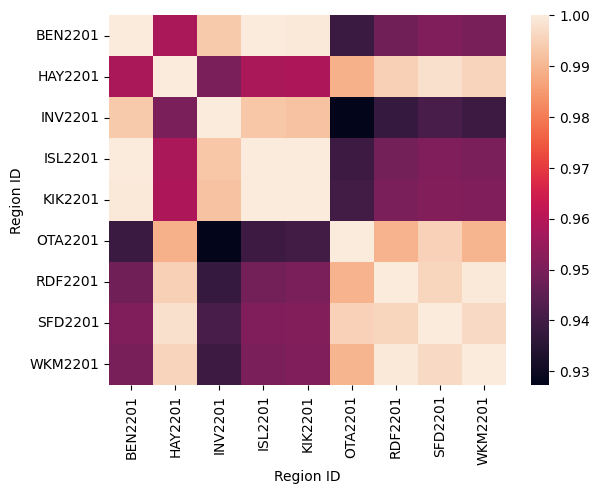

In [7]:
sns.heatmap(price_df.select_dtypes(include='float64').corr())


## Demand

In [8]:
# Pivot regions to deisplay demand GHW in the same rows

demand_df = demand_df.pivot(index='Period start', columns='Region ID', values='Demand (GWh)')
demand_df = demand_df.reset_index()

In [9]:
# Display Stuff
demand_df.info()
demand_df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87648 entries, 0 to 87647
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Period start  87648 non-null  object 
 1   CNI           87581 non-null  float64
 2   LNI           87572 non-null  float64
 3   LSI           87553 non-null  float64
 4   UNI           87564 non-null  float64
 5   USI           87561 non-null  float64
dtypes: float64(5), object(1)
memory usage: 4.0+ MB


Region ID,Period start,CNI,LNI,LSI,UNI,USI
0,01/01/2021 00:00:00,0.345,0.215,0.461,0.471,0.242
1,01/01/2021 00:30:00,0.335,0.209,0.455,0.461,0.236
2,01/01/2021 01:00:00,0.328,0.203,0.449,0.454,0.225
3,01/01/2021 01:30:00,0.321,0.197,0.445,0.439,0.213
4,01/01/2021 02:00:00,0.314,0.192,0.445,0.430,0.204
5,01/01/2021 02:30:00,0.309,0.189,0.444,0.421,0.198
6,01/01/2021 03:00:00,0.305,0.186,0.442,0.415,0.193
7,01/01/2021 03:30:00,0.304,0.184,0.440,0.412,0.190
8,01/01/2021 04:00:00,0.304,0.183,0.440,0.409,0.191
9,01/01/2021 04:30:00,0.308,0.185,0.442,0.407,0.195


In [ ]:
#display more stuff
plt.figure(figsize=(14,3))
sns.lineplot(data=demand_df.set_index('Period start'))
plt.ylabel('El. Demand (GWh)')
plt.tight_layout()

<Axes: xlabel='Region ID', ylabel='Region ID'>

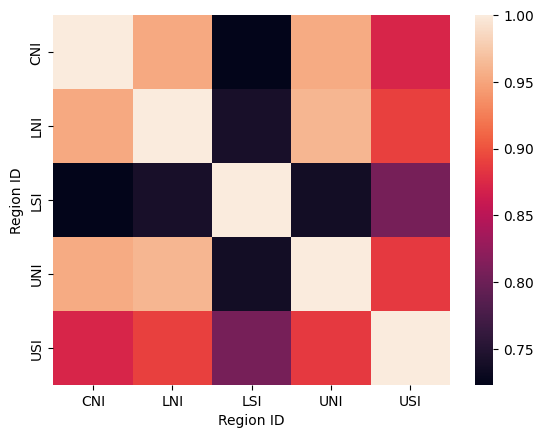

In [ ]:
sns.heatmap(demand_df.select_dtypes(include='float64').corr())

## Electricity Generation

In [ ]:
# Pivot regions to deisplay generation GHW in the same rows

generation_df = generation_df.pivot(index='Period start', columns='Region ID', values='Generation (GWh)')
generation_df = generation_df.reset_index()

In [ ]:
# Display Stuff
generation_df.info()
generation_df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87648 entries, 0 to 87647
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Period start  87648 non-null  object 
 1   CNI           87648 non-null  float64
 2   LNI           87648 non-null  float64
 3   LSI           87648 non-null  float64
 4   UNI           87648 non-null  float64
 5   USI           87648 non-null  float64
dtypes: float64(5), object(1)
memory usage: 4.0+ MB


Region ID,Period start,CNI,LNI,LSI,UNI,USI
0,01/01/2022 00:00:00,0.708,0.243,0.813,0.047,0.030
1,01/01/2022 00:30:00,0.689,0.258,0.771,0.047,0.032
2,01/01/2022 01:00:00,0.670,0.237,0.760,0.047,0.031
3,01/01/2022 01:30:00,0.670,0.215,0.737,0.047,0.026
4,01/01/2022 02:00:00,0.671,0.194,0.724,0.048,0.026
5,01/01/2022 02:30:00,0.670,0.170,0.727,0.047,0.020
6,01/01/2022 03:00:00,0.660,0.178,0.713,0.047,0.020
7,01/01/2022 03:30:00,0.661,0.165,0.715,0.047,0.019
8,01/01/2022 04:00:00,0.669,0.147,0.722,0.047,0.019
9,01/01/2022 04:30:00,0.673,0.147,0.725,0.047,0.019


Text(0, 0.5, 'El. generation (GWh)')

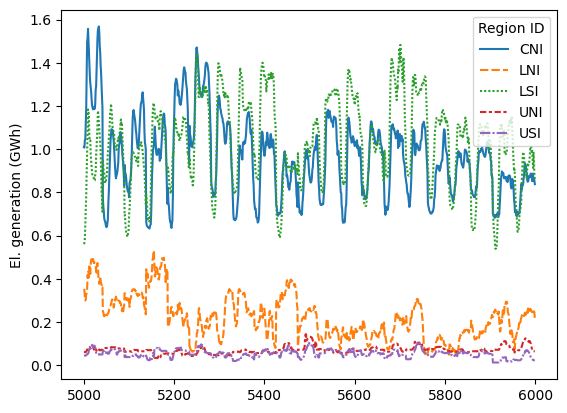

In [ ]:
#display more stuff
sns.lineplot(data=generation_df[5000:6000])
plt.ylabel('El. generation (GWh)')

<Axes: xlabel='Region ID', ylabel='Region ID'>

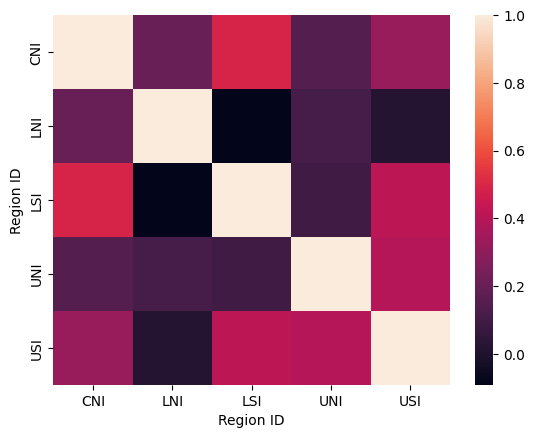

In [ ]:
sns.heatmap(generation_df.select_dtypes(include='float64').corr())

## HVDC line transfer

In [ ]:
# Pivot regions to deisplay generation GHW in the same rows

HVDC_df.drop(columns='Trading period')

,Period start,Period end,Direction,Energy transfer (GWh),Peak flow (MW),Average flow (MW)
0,01/01/2021 00:00:00,01/01/2021 00:30:00,Northward at Haywards,0.072,143,143
1,01/01/2021 00:30:00,01/01/2021 01:00:00,Northward at Haywards,0.061,122,122
2,01/01/2021 01:00:00,01/01/2021 01:30:00,Northward at Haywards,0.030,60,60
3,01/01/2021 01:30:00,01/01/2021 02:00:00,Northward at Haywards,0.040,79,79
4,01/01/2021 02:00:00,01/01/2021 02:30:00,Northward at Haywards,0.042,83,83
...,...,...,...,...,...,...
86958,31/12/2025 21:30:00,31/12/2025 22:00:00,Northward at Haywards,0.270,540,540
86959,31/12/2025 22:00:00,31/12/2025 22:30:00,Northward at Haywards,0.242,484,484
86960,31/12/2025 22:30:00,31/12/2025 23:00:00,Northward at Haywards,0.239,477,477
86961,31/12/2025 23:00:00,31/12/2025 23:30:00,Northward at Haywards,0.232,464,464


In [ ]:
# Display Stuff
HVDC_df.info()
HVDC_df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86963 entries, 0 to 86962
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Period start           86963 non-null  object 
 1   Period end             86963 non-null  object 
 2   Trading period         86963 non-null  int64  
 3   Direction              86963 non-null  object 
 4   Energy transfer (GWh)  86963 non-null  float64
 5   Peak flow (MW)         86963 non-null  int64  
 6   Average flow (MW)      86963 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 4.6+ MB


,Period start,Period end,Trading period,Direction,Energy transfer (GWh),Peak flow (MW),Average flow (MW)
0,01/01/2021 00:00:00,01/01/2021 00:30:00,1,Northward at Haywards,0.072,143,143
1,01/01/2021 00:30:00,01/01/2021 01:00:00,2,Northward at Haywards,0.061,122,122
2,01/01/2021 01:00:00,01/01/2021 01:30:00,3,Northward at Haywards,0.030,60,60
3,01/01/2021 01:30:00,01/01/2021 02:00:00,4,Northward at Haywards,0.040,79,79
4,01/01/2021 02:00:00,01/01/2021 02:30:00,5,Northward at Haywards,0.042,83,83
5,01/01/2021 02:30:00,01/01/2021 03:00:00,6,Northward at Haywards,0.036,71,71
6,01/01/2021 03:00:00,01/01/2021 03:30:00,7,Northward at Haywards,0.036,71,71
7,01/01/2021 03:30:00,01/01/2021 04:00:00,8,Northward at Haywards,0.035,70,70
8,01/01/2021 04:00:00,01/01/2021 04:30:00,9,Northward at Haywards,0.035,70,70
9,01/01/2021 04:30:00,01/01/2021 05:00:00,10,Northward at Haywards,0.039,77,77


Text(0, 0.5, 'ENergyflow')

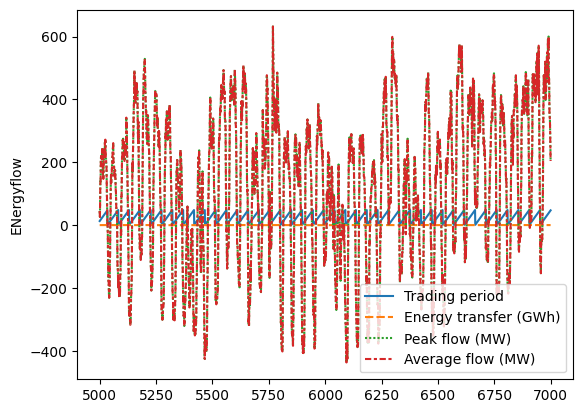

In [ ]:
#display more stuff
sns.lineplot(data=HVDC_df[5000:7000])
plt.ylabel('ENergyflow')

## lake storage level

In [ ]:

lake1_df.head()

,Date,Time,Lake level (m),Active storage (Mm³),Active contingent storage (Mm³),QualityCode
0,1980-03-18,23:59:59,356.790,574.629,NaN,320.0
1,1980-06-16,23:59:59,356.982,692.061,NaN,320.0
2,1980-10-09,23:59:59,356.968,683.315,NaN,320.0
3,1981-02-05,23:59:59,356.756,554.143,NaN,320.0
4,1981-06-06,23:59:59,356.302,276.657,NaN,320.0


In [ ]:
lake2_df.head()


,Date,Time,Lake level (m),Active storage (Mm³),Active contingent storage (Mm³),QualityCode
0,1980-06-25,23:59:59,583.717,179.856,NaN,320.0
1,1981-04-08,23:59:59,581.304,53.400,NaN,320.0
2,1981-12-15,23:59:59,581.889,84.056,NaN,320.0
3,1981-12-19,23:59:59,581.788,78.765,NaN,320.0
4,1983-07-08,23:59:59,580.118,0.000,NaN,320.0


In [ ]:
lake1_df.info()
lake2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16438 entries, 0 to 16437
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             16437 non-null  object 
 1   Time                             16438 non-null  object 
 2   Lake level (m)                   16437 non-null  float64
 3   Active storage (Mm³)             16437 non-null  float64
 4   Active contingent storage (Mm³)  0 non-null      float64
 5   QualityCode                      16437 non-null  float64
dtypes: float64(4), object(2)
memory usage: 770.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16438 entries, 0 to 16437
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             16437 non-null  object 
 1   Time                             16438 non-

## Wind

In [ ]:
wind_df.head()

,Unnamed: 0,time,Timaro_wind_kmh,Timaro_wind_direction_deg,Southern_Tip_wind_kmh,Southern_Tip_wind_direction_deg,Wellington_wind_kmh,Wellington_wind_direction_deg,Palmerston North_wind_kmh,Palmerston North_wind_direction_deg,Raglan_wind_kmh,Raglan_wind_direction_deg
0,0,2021-01-01 00:00:00,24.7,37,5.4,138,16.4,38,19.5,74,8.0,342
1,1,2021-01-01 01:00:00,22.7,33,4.6,141,17.0,21,16.1,66,8.3,358
2,2,2021-01-01 02:00:00,20.1,29,8.9,159,15.1,1,12.2,45,8.1,347
3,3,2021-01-01 03:00:00,17.6,28,13.3,180,14.1,341,9.7,22,8.9,339
4,4,2021-01-01 04:00:00,16.1,29,12.9,203,17.7,336,8.6,358,7.9,330


In [ ]:
wind_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46704 entries, 0 to 46703
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Unnamed: 0                           46704 non-null  int64  
 1   time                                 46704 non-null  object 
 2   Timaro_wind_kmh                      46704 non-null  float64
 3   Timaro_wind_direction_deg            46704 non-null  int64  
 4   Southern_Tip_wind_kmh                46704 non-null  float64
 5   Southern_Tip_wind_direction_deg      46704 non-null  int64  
 6   Wellington_wind_kmh                  46704 non-null  float64
 7   Wellington_wind_direction_deg        46704 non-null  int64  
 8   Palmerston North_wind_kmh            46704 non-null  float64
 9   Palmerston North_wind_direction_deg  46704 non-null  int64  
 10  Raglan_wind_kmh                      46704 non-null  float64
 11  Raglan_wind_direction_deg   